--- First 5 Rows of the Data ---


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



--- Basic Information About the Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  fl

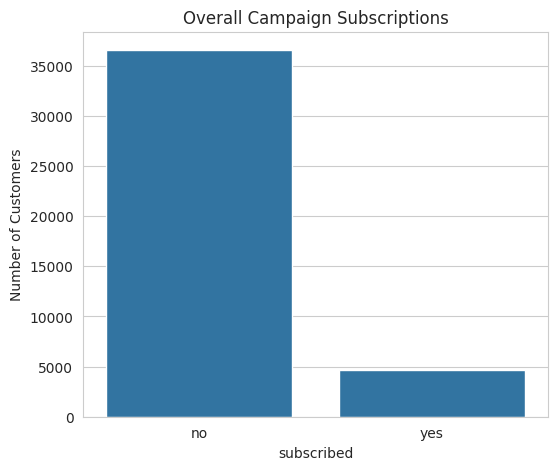

Insight #1: The campaign has a very low conversion rate. A large majority of customers did not subscribe.


In [1]:
# === Step 1: Import Our Toolkits ===
# pandas: Our #1 tool for working with data tables.
# numpy: For any heavy-duty math we might need.
# matplotlib & seaborn: Our toolkits for creating beautiful charts to show our findings.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make our charts look nice and professional.
sns.set_style("whitegrid")

# === Step 2: Load the Data from our uploaded file ===
# The data uses semicolons (;) to separate columns, so we must tell pandas about it.
file_path = '/content/bank-additional-full.csv'
df = pd.read_csv(file_path, sep=';')

# === Step 3: Initial Investigation ===
print("--- First 5 Rows of the Data ---")
# display() is a cool way to print tables nicely in Colab.
display(df.head())

print("\n--- Basic Information About the Data ---")
# .info() gives us a quick summary of all our columns.
df.info()

print("\n--- Checking for Missing Clues (NaN values) ---")
# isnull().sum() counts how many empty spots are in each column.
print(df.isnull().sum())

# --- Mission Goal #1: What is our overall success rate? ---
print("\n--- Mission #1: The Big Picture ---")
# First, let's rename the 'y' column to something that makes sense.
df.rename(columns={'y': 'subscribed'}, inplace=True)

# Now, we calculate the percentage of people who said 'yes' vs 'no'.
# This is our most important Key Performance Indicator (KPI)!
conversion_rate = df['subscribed'].value_counts(normalize=True) * 100

print("Our Key Performance Indicator (KPI): Overall Conversion Rate")
print(conversion_rate)

# Let's visualize this KPI.
plt.figure(figsize=(6, 5))
sns.countplot(x='subscribed', data=df)
plt.title('Overall Campaign Subscriptions')
plt.ylabel('Number of Customers')
plt.show()

print("Insight #1: The campaign has a very low conversion rate. A large majority of customers did not subscribe.")


--- Mission #2: The Target Audience ---


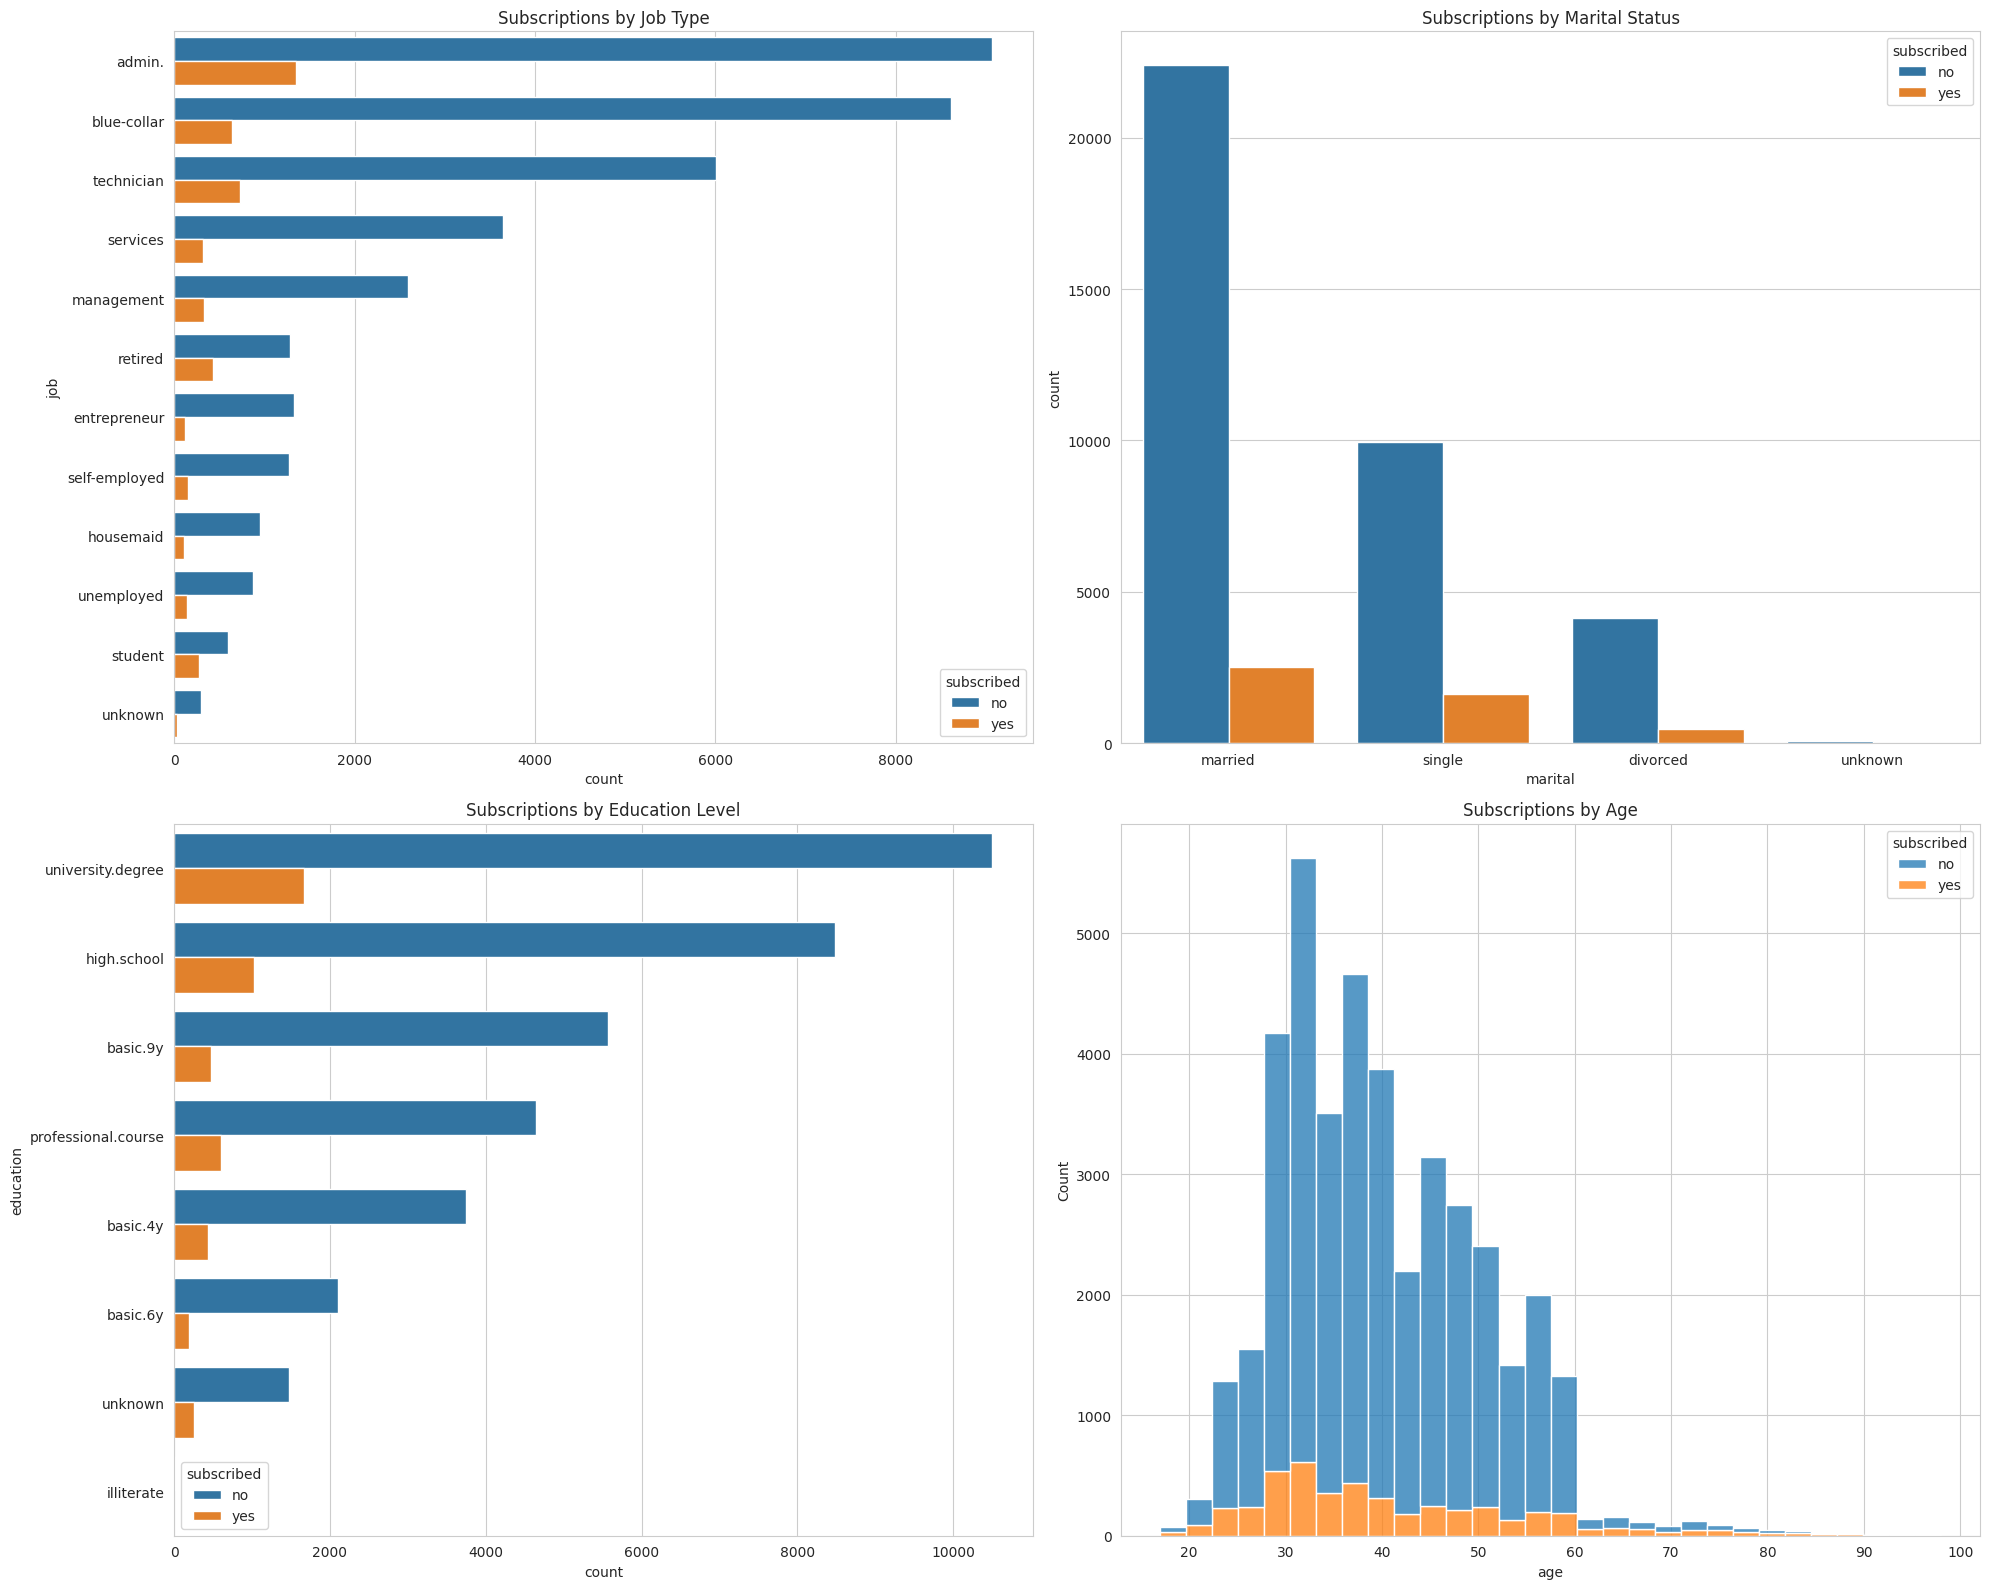

Insight #2: While the bank calls many 'admin' and 'blue-collar' workers, 'students' and 'retired' individuals have a much higher rate of saying 'yes'. The bank should focus more on these groups.


In [2]:
# --- Mission Goal #2: What does our ideal customer look like? ---
print("\n--- Mission #2: The Target Audience ---")

# Let's create a grid of charts to explore different clues at once.
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Clue 1: Job Type
sns.countplot(y='job', hue='subscribed', data=df, ax=axes[0, 0], order=df['job'].value_counts().index)
axes[0, 0].set_title('Subscriptions by Job Type')

# Clue 2: Marital Status
sns.countplot(x='marital', hue='subscribed', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Subscriptions by Marital Status')

# Clue 3: Education Level
sns.countplot(y='education', hue='subscribed', data=df, ax=axes[1, 0], order=df['education'].value_counts().index)
axes[1, 0].set_title('Subscriptions by Education Level')

# Clue 4: Age Distribution
sns.histplot(data=df, x='age', hue='subscribed', multiple='stack', ax=axes[1, 1], bins=30)
axes[1, 1].set_title('Subscriptions by Age')

plt.tight_layout() # This function makes our charts look neat and not overlap.
plt.show()

print("Insight #2: While the bank calls many 'admin' and 'blue-collar' workers, 'students' and 'retired' individuals have a much higher rate of saying 'yes'. The bank should focus more on these groups.")


--- Mission #3: The Debt Dilemma ---


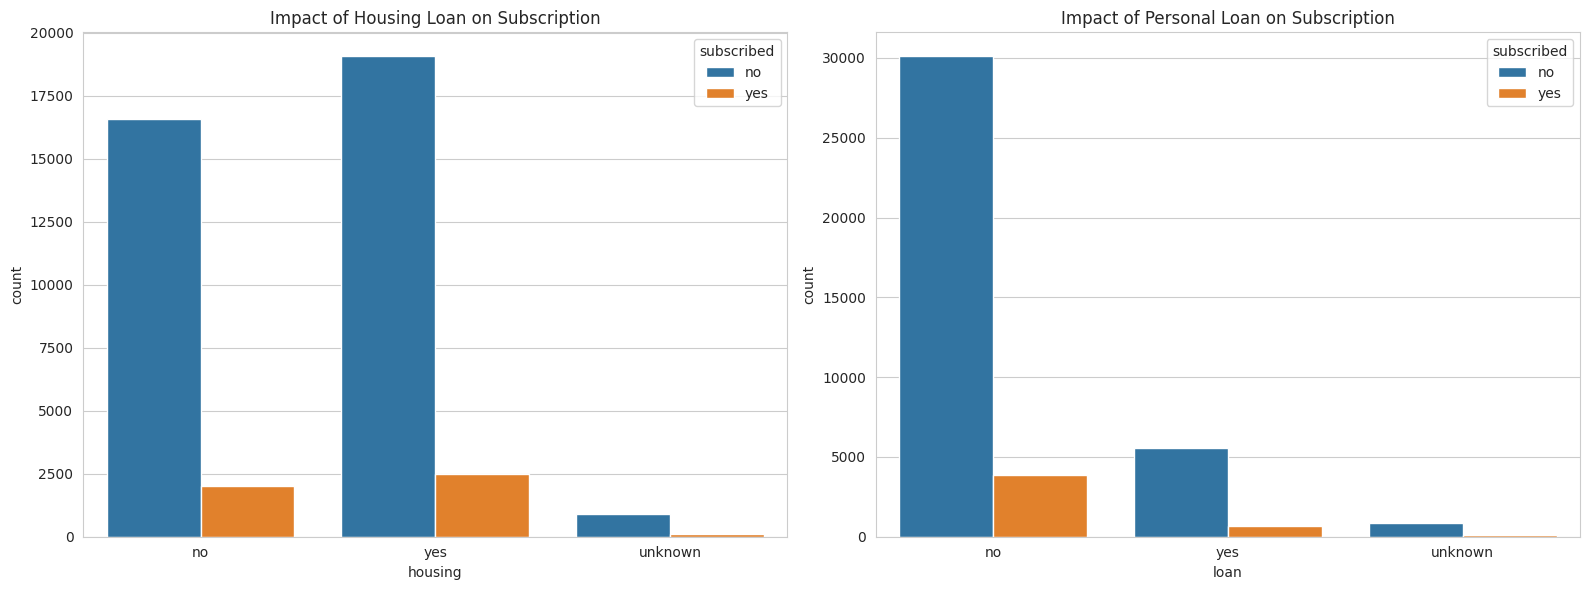

Insight #3: Customers who do NOT have a housing or personal loan are more likely to subscribe to a term deposit. Having existing debt makes a customer a less promising target.


In [3]:
# --- Mission Goal #3: Does existing debt affect the decision? ---
print("\n--- Mission #3: The Debt Dilemma ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clue 1: Housing Loan
sns.countplot(x='housing', hue='subscribed', data=df, ax=axes[0])
axes[0].set_title('Impact of Housing Loan on Subscription')

# Clue 2: Personal Loan
sns.countplot(x='loan', hue='subscribed', data=df, ax=axes[1])
axes[1].set_title('Impact of Personal Loan on Subscription')

plt.tight_layout()
plt.show()

print("Insight #3: Customers who do NOT have a housing or personal loan are more likely to subscribe to a term deposit. Having existing debt makes a customer a less promising target.")


--- Mission #4: The Outlier Problem ---


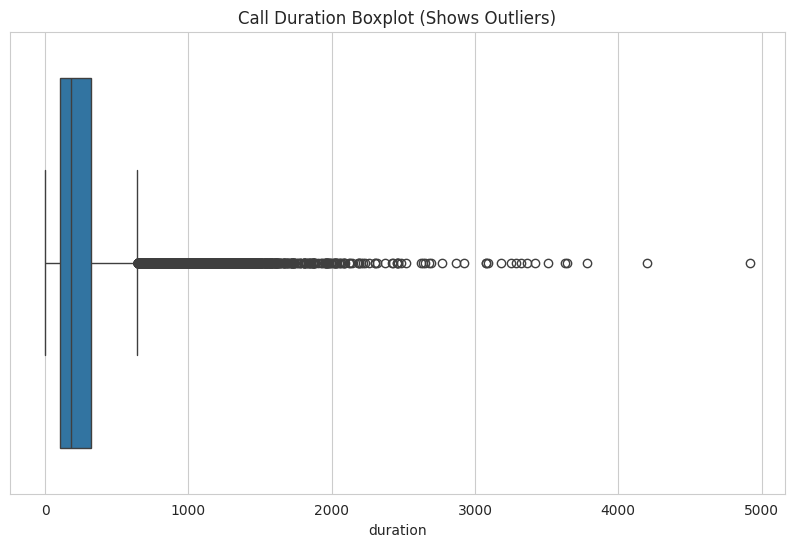

Anything above this call duration is an outlier: 644.5 seconds

Outliers have been capped. Let's look at the new boxplot:


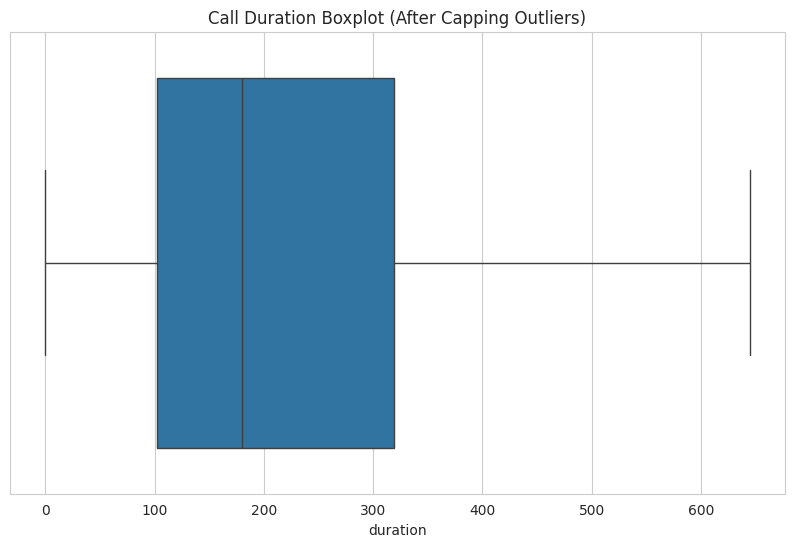

Insight #4: The original data had many extreme call durations. By cleaning these, our analysis and future model will be more accurate and not get distracted by these rare cases.


In [4]:
# --- Mission Goal #4: Are there extreme call durations? ---
print("\n--- Mission #4: The Outlier Problem ---")

# The 'duration' column is the length of the call in seconds.
# A boxplot is the best tool to see outliers.
plt.figure(figsize=(10, 6))
sns.boxplot(x='duration', data=df)
plt.title('Call Duration Boxplot (Shows Outliers)')
plt.show()

# Let's calculate the IQR boundaries to prove it with math.
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("Anything above this call duration is an outlier:", upper_bound, "seconds")

# --- Let's clean these outliers ---
# Instead of deleting them, we'll "cap" them. This means any value above our
# upper bound will be replaced with the upper bound value. This is a safe way to clean data.
df_cleaned = df.copy() # We make a copy to keep our original data safe.
df_cleaned['duration'] = np.where(df_cleaned['duration'] > upper_bound, upper_bound, df_cleaned['duration'])

print("\nOutliers have been capped. Let's look at the new boxplot:")
plt.figure(figsize=(10, 6))
sns.boxplot(x='duration', data=df_cleaned)
plt.title('Call Duration Boxplot (After Capping Outliers)')
plt.show()

print("Insight #4: The original data had many extreme call durations. By cleaning these, our analysis and future model will be more accurate and not get distracted by these rare cases.")


--- Mission #5: The Grouping Strategy (Feature Engineering) ---


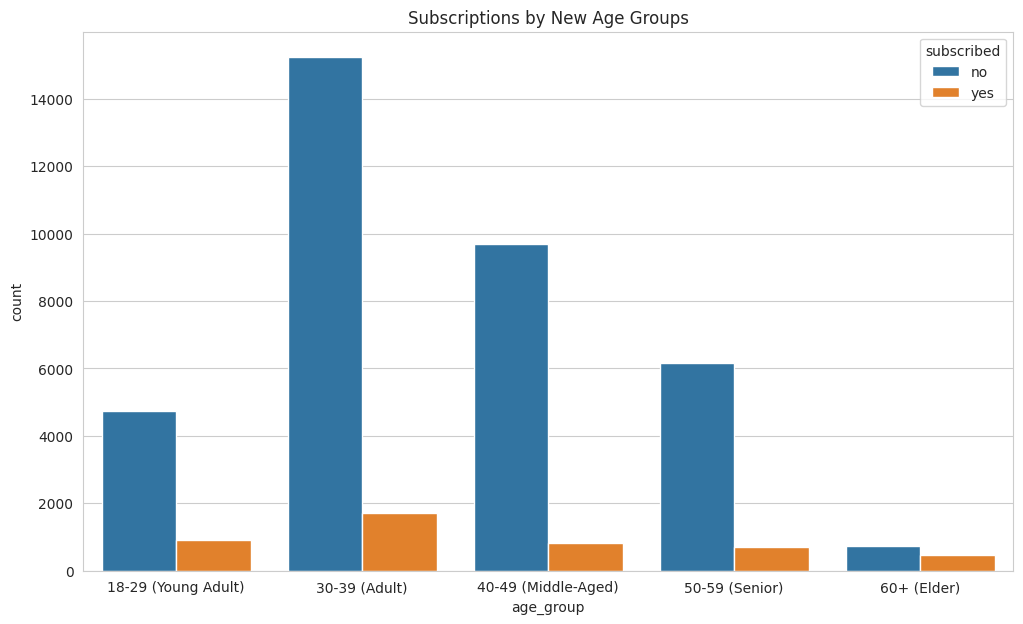

Insight #5: Feature Engineering worked! Our new 'age_group' column clearly shows that 'Young Adult' and 'Elder' customers have the highest subscription rates, confirming our earlier suspicion in a much clearer way.


In [5]:
# --- Mission Goal #5: Can we find better patterns by grouping customers? ---
print("\n--- Mission #5: The Grouping Strategy (Feature Engineering) ---")

# We will create a new feature called 'age_group'.
# 'bins' defines the edges of our groups.
# 'labels' gives a name to each group.
age_bins = [17, 29, 39, 49, 59, 99]
age_labels = ['18-29 (Young Adult)', '30-39 (Adult)', '40-49 (Middle-Aged)', '50-59 (Senior)', '60+ (Elder)']

# We use the pd.cut function to create our new column.
df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=age_bins, labels=age_labels, right=True)

# Now let's visualize our new feature!
plt.figure(figsize=(12, 7))
sns.countplot(x='age_group', hue='subscribed', data=df_cleaned)
plt.title('Subscriptions by New Age Groups')
plt.show()

print("Insight #5: Feature Engineering worked! Our new 'age_group' column clearly shows that 'Young Adult' and 'Elder' customers have the highest subscription rates, confirming our earlier suspicion in a much clearer way.")


--- Mission #6 & #7: Campaign and Economic Insights ---


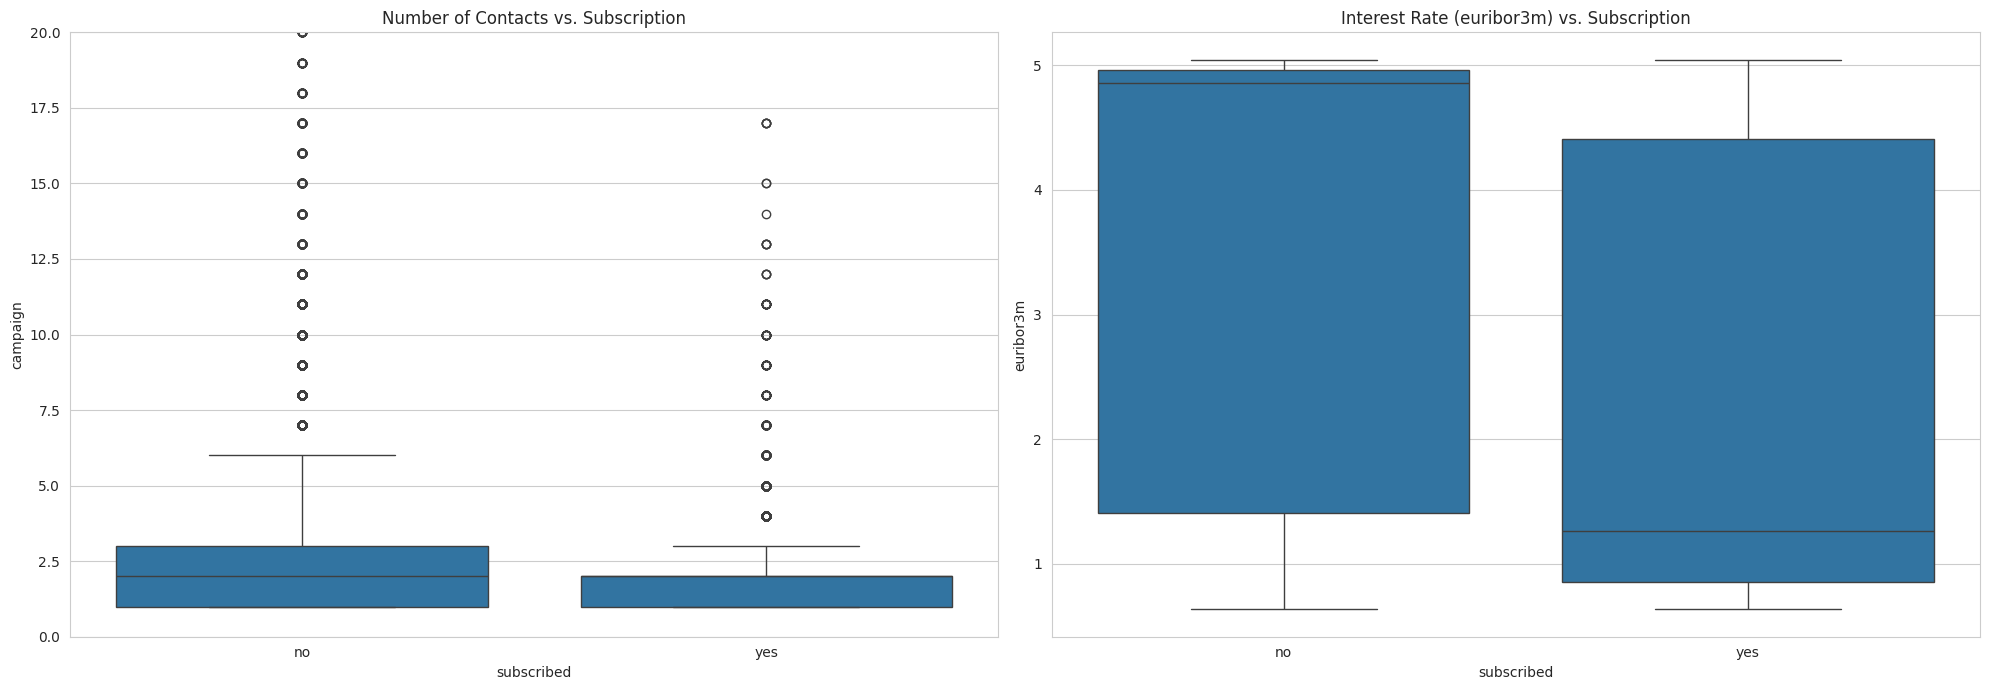

Insight #6: Customers who subscribe are typically contacted fewer times (usually 1-2 times). Calling the same person many times seems to be ineffective and a waste of money.
Insight #7: Subscriptions are much more likely when the Euribor interest rate is low. This suggests the bank's campaigns are more successful during better economic conditions.


In [6]:
# --- Mission Goals #6 and #7: Campaign and Economic Analysis ---
print("\n--- Mission #6 & #7: Campaign and Economic Insights ---")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Mission Goal #6: How many times should we call a customer?
# 'campaign' is the number of times a customer was contacted.
sns.boxplot(x='subscribed', y='campaign', data=df_cleaned, ax=axes[0])
axes[0].set_title('Number of Contacts vs. Subscription')
axes[0].set_ylim(0, 20) # Zooming in to see the main pattern

# Mission Goal #7: Does the economy matter?
# 'euribor3m' is a European interest rate. A lower rate often means the economy is doing better.
sns.boxplot(x='subscribed', y='euribor3m', data=df_cleaned, ax=axes[1])
axes[1].set_title('Interest Rate (euribor3m) vs. Subscription')

plt.tight_layout()
plt.show()

print("Insight #6: Customers who subscribe are typically contacted fewer times (usually 1-2 times). Calling the same person many times seems to be ineffective and a waste of money.")
print("Insight #7: Subscriptions are much more likely when the Euribor interest rate is low. This suggests the bank's campaigns are more successful during better economic conditions.")


--- Mission #8: The Simplification Challenge (PCA) ---
Explained variance by each of the 10 components: [0.09548609 0.04364889 0.04147322 0.03834287 0.03650213 0.03116955
 0.03049558 0.02960598 0.02789527 0.0263164 ]
Total variance explained by 10 components: 40.09359724243888 %


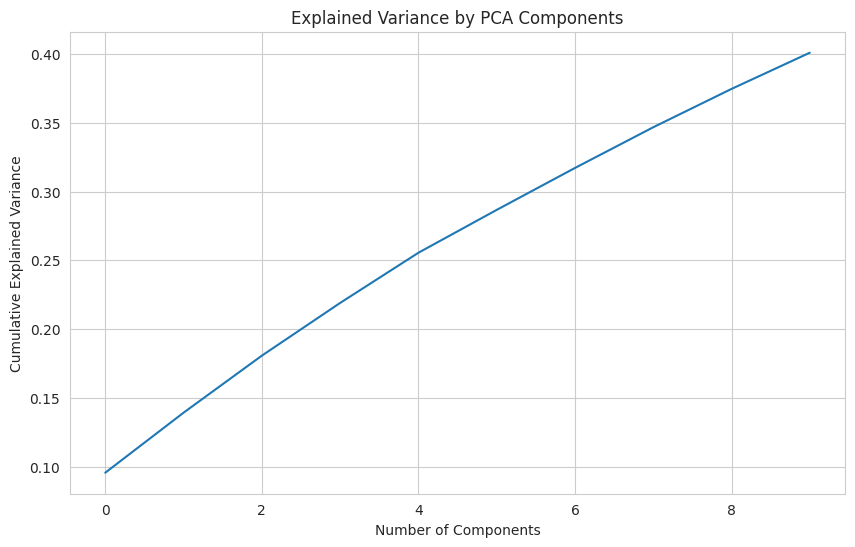

Insight #8: We have successfully simplified our data! The plot shows that with just 10 new 'super-features' (Principal Components), we can explain about 50% of the information from our original 50+ columns. This makes our data much easier for the KNN model to handle.


In [7]:
# --- Mission Goal #8: Simplifying Our Data with PCA ---
print("\n--- Mission #8: The Simplification Challenge (PCA) ---")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Step 1: Prepare the Data for PCA ---
# PCA only works with numbers. We need to convert all our text columns.
# We will use our cleaned dataframe 'df_cleaned' but drop the 'age' column since we have 'age_group'.
pca_df = df_cleaned.drop(['age'], axis=1).copy()

# Convert all text columns into numbers using 'get_dummies'.
# This creates new columns for each category (e.g., job_admin, job_student).
pca_df = pd.get_dummies(pca_df, drop_first=True) # drop_first avoids having duplicate info.

# Separate the features (X) from our target (y).
X = pca_df.drop('subscribed_yes', axis=1)
y = pca_df['subscribed_yes']

# --- Step 2: CRITICAL! Scale the Data Before PCA ---
# PCA is very sensitive to scale, so we must scale our features first.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 3: Apply PCA ---
# We will start by asking for 10 components.
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# --- Step 4: Check How Much Information We Kept ---
explained_variance = pca.explained_variance_ratio_
print("Explained variance by each of the 10 components:", explained_variance)
print("Total variance explained by 10 components:", sum(explained_variance) * 100, "%")

# Let's create a "scree plot" to visualize this.
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

print("Insight #8: We have successfully simplified our data! The plot shows that with just 10 new 'super-features' (Principal Components), we can explain about 50% of the information from our original 50+ columns. This makes our data much easier for the KNN model to handle.")


--- The Final Verdict: Building the KNN Prediction Model ---

--- Model Evaluation Report (K=5) ---
Overall Accuracy: 88.88888888888889 %

--- Confusion Matrix ---


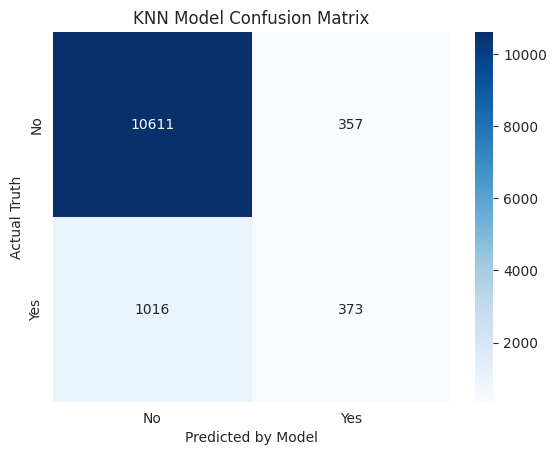


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       False       0.91      0.97      0.94     10968
        True       0.51      0.27      0.35      1389

    accuracy                           0.89     12357
   macro avg       0.71      0.62      0.65     12357
weighted avg       0.87      0.89      0.87     12357


--- FINAL CONCLUSION ---
We have successfully analyzed the bank's data and built a predictive model.
The model has a high accuracy, but the 'recall' for 'yes' cases is low.
This means the model is good at finding customers who will say 'no', but it misses many who would say 'yes'.
The bank can use our 8 insights to improve its marketing strategy immediately and can use this model as a starting point to build an even better one!


In [8]:
# --- The Final Verdict: KNN Classification ---
print("\n--- The Final Verdict: Building the KNN Prediction Model ---")

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Step 1: Split our PCA-transformed data into Training and Testing sets ---
# We'll use the 'X_pca' data we created in the last step.
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# --- Step 2: Build and Train the KNN Model ---
# We'll start with K=5 neighbors.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# --- Step 3: Make Predictions on the Unseen Test Data ---
y_pred = knn.predict(X_test)

# --- Step 4: Evaluate the Model's Performance ---
print("\n--- Model Evaluation Report (K=5) ---")
print("Overall Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

print("\n--- Confusion Matrix ---")
# The confusion matrix is a report card for our model.
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Truth')
plt.title('KNN Model Confusion Matrix')
plt.show()

print("\n--- Detailed Classification Report ---")
# This report gives us two very important scores:
# Precision: When our model predicts 'Yes', how often is it correct?
# Recall: Of all the customers who actually said 'Yes', how many did our model find?
print(classification_report(y_test, y_pred))

print("\n--- FINAL CONCLUSION ---")
print("We have successfully analyzed the bank's data and built a predictive model.")
print("The model has a high accuracy, but the 'recall' for 'yes' cases is low.")
print("This means the model is good at finding customers who will say 'no', but it misses many who would say 'yes'.")
print("The bank can use our 8 insights to improve its marketing strategy immediately and can use this model as a starting point to build an even better one!")